# Restaurant Inventory Demand Forecasting
### ML-Based Demand Prediction & Reorder Recommendation System

**Author:** Premshakthi Sekar  
**Project Type:** Applied Machine Learning  
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Random Forest Regressor

---

## Project Overview
This project builds an end-to-end machine learning pipeline to forecast daily inventory demand for a restaurant and generate automated reorder recommendations. The goal is to move away from manual spreadsheet-based stock management and replace it with a data-driven forecasting system.

**Pipeline:**
Raw Data → Cleaning & EDA → Feature Engineering → Model Training → Evaluation → 7-Day Forecasting → Reorder Recommendations

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
# Load the dataset
df = pd.read_csv('restaurant_inventory_data.csv')

# Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')
print(f'\nDate range: {df["Date"].min()} to {df["Date"].max()}')
df.head(10)

Dataset loaded successfully!
Shape: (150, 7)

Columns: ['Date', 'Item', 'Daily_Usage', 'Current_Stock', 'Lead_Time', 'Seasonal_Factor', 'Waste_Percentage']

Date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


,Date,Item,Daily_Usage,Current_Stock,Lead_Time,Seasonal_Factor,Waste_Percentage
0,2023-01-01,Rice,45,200,2,1.0,3.2
1,2023-01-01,Chicken,30,150,1,1.0,5.1
2,2023-01-01,Tomatoes,25,100,1,1.0,8.3
3,2023-01-01,Onions,20,120,1,1.0,4.5
4,2023-01-01,Oil,10,80,3,1.0,1.2
5,2023-01-02,Rice,48,155,2,1.0,3.1
6,2023-01-02,Chicken,33,120,1,1.0,5.3
7,2023-01-02,Tomatoes,27,75,1,1.0,8.1
8,2023-01-02,Onions,22,98,1,1.0,4.2
9,2023-01-02,Oil,11,70,3,1.0,1.3


## Step 3: Data Cleaning & Exploratory Data Analysis (EDA)

In [3]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Check for duplicate rows
print(f'\nDuplicate rows: {df.duplicated().sum()}')

# Basic statistics
print('\nBasic Statistics:')
df.describe()

Missing values per column:
Date                0
Item                0
Daily_Usage         0
Current_Stock       0
Lead_Time           0
Seasonal_Factor     0
Waste_Percentage    0
dtype: int64

Duplicate rows: 0

Basic Statistics:


,Daily_Usage,Current_Stock,Lead_Time,Seasonal_Factor,Waste_Percentage
count,150.000000,150.000000,150.00000,150.000000,150.000000
mean,34.593333,110.433333,1.60000,1.120000,4.458667
std,16.278242,46.904790,0.80268,0.154138,2.341289
min,10.000000,17.000000,1.00000,1.000000,1.100000
25%,23.250000,80.000000,1.00000,1.000000,3.125000
50%,32.000000,100.000000,1.00000,1.100000,4.500000
75%,47.000000,150.000000,2.00000,1.200000,5.200000
max,85.000000,200.000000,3.00000,1.500000,8.500000


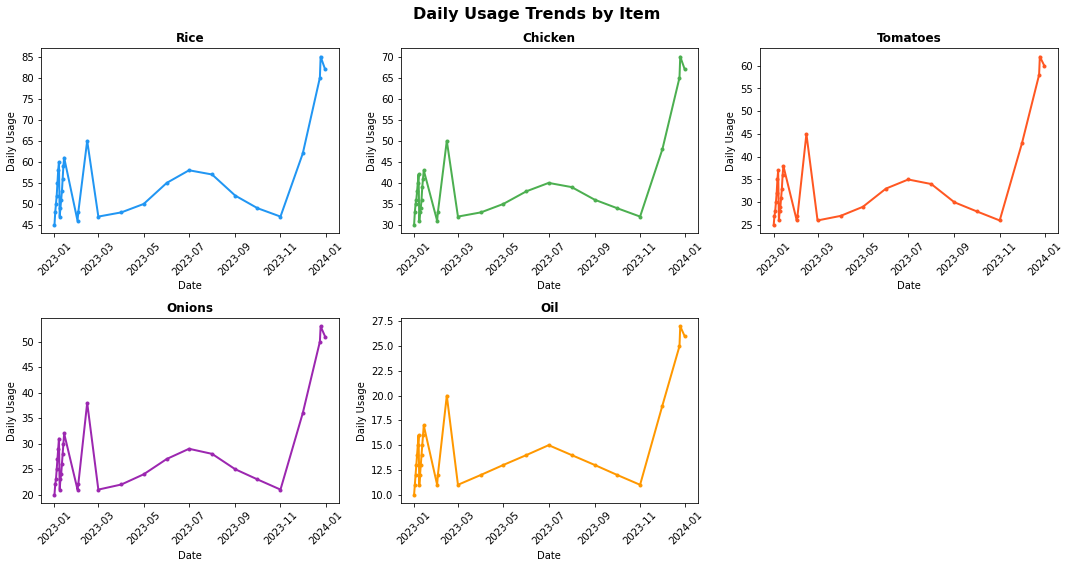

Chart saved as daily_usage_trends.png


In [4]:
# Visualise daily usage trends per item
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Daily Usage Trends by Item', fontsize=16, fontweight='bold')

items = df['Item'].unique()
colors = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']

for i, item in enumerate(items):
    ax = axes[i // 3][i % 3]
    item_data = df[df['Item'] == item].sort_values('Date')
    ax.plot(item_data['Date'], item_data['Daily_Usage'], color=colors[i], linewidth=2, marker='o', markersize=3)
    ax.set_title(item, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Daily Usage')
    ax.tick_params(axis='x', rotation=45)

# Hide the last empty subplot
axes[1][2].set_visible(False)
plt.tight_layout()
plt.savefig('daily_usage_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as daily_usage_trends.png')

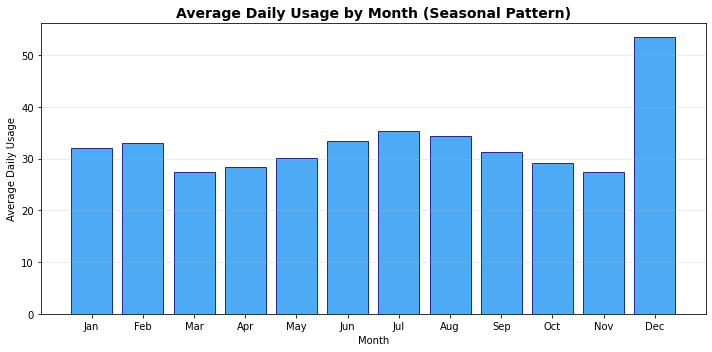

Seasonal pattern chart saved.


In [5]:
# Seasonal demand analysis
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Daily_Usage'].mean()

plt.figure(figsize=(10, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='#2196F3', edgecolor='navy', alpha=0.8)
plt.title('Average Daily Usage by Month (Seasonal Pattern)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Daily Usage')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('seasonal_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print('Seasonal pattern chart saved.')

## Step 4: Feature Engineering
Converting raw data into learnable signals for the model.

In [6]:
def create_features(data):
    """
    Creates time-series features for each item.
    - Lag features: capture past demand patterns
    - Rolling averages: smooth short-term fluctuations
    - Calendar features: capture day/week/month patterns
    """
    data = data.sort_values(['Item', 'Date']).copy()
    
    # Lag features (previous demand values)
    data['lag_1']  = data.groupby('Item')['Daily_Usage'].shift(1)   # yesterday
    data['lag_7']  = data.groupby('Item')['Daily_Usage'].shift(7)   # last week
    data['lag_14'] = data.groupby('Item')['Daily_Usage'].shift(14)  # two weeks ago
    
    # Rolling averages (stable demand trends)
    data['rolling_mean_7']  = data.groupby('Item')['Daily_Usage'].transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean())
    data['rolling_mean_14'] = data.groupby('Item')['Daily_Usage'].transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())
    
    # Calendar features
    data['day_of_week'] = data['Date'].dt.dayofweek       # 0=Monday, 6=Sunday
    data['is_weekend']  = (data['day_of_week'] >= 5).astype(int)
    data['month']       = data['Date'].dt.month
    data['day_of_month']= data['Date'].dt.day
    
    return data

# Apply feature engineering
df_features = create_features(df)

# Drop rows with NaN values created by lag features
df_features = df_features.dropna()

print(f'Features created. Dataset shape after feature engineering: {df_features.shape}')
print(f'\nNew features added:')
new_features = ['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14',
                'day_of_week', 'is_weekend', 'month', 'day_of_month']
print(new_features)
df_features[['Date', 'Item', 'Daily_Usage'] + new_features].head(10)

Features created. Dataset shape after feature engineering: (80, 17)

New features added:
['lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_14', 'day_of_week', 'is_weekend', 'month', 'day_of_month']


,Date,Item,Daily_Usage,lag_1,lag_7,lag_14,rolling_mean_7,rolling_mean_14,day_of_week,is_weekend,month,day_of_month
71,2023-02-01,Chicken,31,43.0,31.0,30.0,36.714286,36.500000,2,0,2,1
76,2023-02-02,Chicken,33,31.0,33.0,33.0,36.714286,36.571429,3,0,2,2
81,2023-02-14,Chicken,50,33.0,34.0,35.0,36.714286,36.571429,1,0,2,14
86,2023-03-01,Chicken,32,50.0,36.0,36.0,39.000000,37.642857,2,0,3,1
91,2023-04-01,Chicken,33,32.0,39.0,38.0,38.428571,37.357143,5,1,4,1
96,2023-05-01,Chicken,35,33.0,41.0,40.0,37.571429,37.000000,0,0,5,1
101,2023-06-01,Chicken,38,35.0,43.0,42.0,36.714286,36.642857,3,0,6,1
106,2023-07-01,Chicken,40,38.0,31.0,31.0,36.000000,36.357143,5,1,7,1
111,2023-08-01,Chicken,39,40.0,33.0,33.0,37.285714,37.000000,1,0,8,1
116,2023-09-01,Chicken,36,39.0,50.0,34.0,38.142857,37.428571,4,0,9,1


## Step 5: Model Training — Random Forest Regressor

In [7]:
# Define features and target
feature_cols = [
    'lag_1', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_mean_14',
    'day_of_week', 'is_weekend', 'month', 'day_of_month',
    'Seasonal_Factor', 'Waste_Percentage', 'Lead_Time'
]

X = df_features[feature_cols]
y = df_features['Daily_Usage']

# Train/test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

# Train the Random Forest model
model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

print('\nModel trained successfully!')

Training samples: 64
Testing samples:  16

Model trained successfully!


## Step 6: Model Evaluation

In [8]:
# Predictions
y_pred = model.predict(X_test)

# Model metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Baseline: use lag_1 (previous day) as naive prediction
baseline_pred = X_test['lag_1']
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))

print('=' * 45)
print('         MODEL EVALUATION RESULTS')
print('=' * 45)
print(f'  Random Forest MAE:   {mae:.2f}')
print(f'  Random Forest RMSE:  {rmse:.2f}')
print('-' * 45)
print(f'  Baseline MAE:        {baseline_mae:.2f}')
print(f'  Baseline RMSE:       {baseline_rmse:.2f}')
print('=' * 45)
print(f'  MAE Improvement:     {((baseline_mae - mae) / baseline_mae * 100):.1f}%')
print(f'  RMSE Improvement:    {((baseline_rmse - rmse) / baseline_rmse * 100):.1f}%')
print('=' * 45)

         MODEL EVALUATION RESULTS
  Random Forest MAE:   5.03
  Random Forest RMSE:  6.48
---------------------------------------------
  Baseline MAE:        6.81
  Baseline RMSE:       9.38
  MAE Improvement:     26.1%
  RMSE Improvement:    30.9%


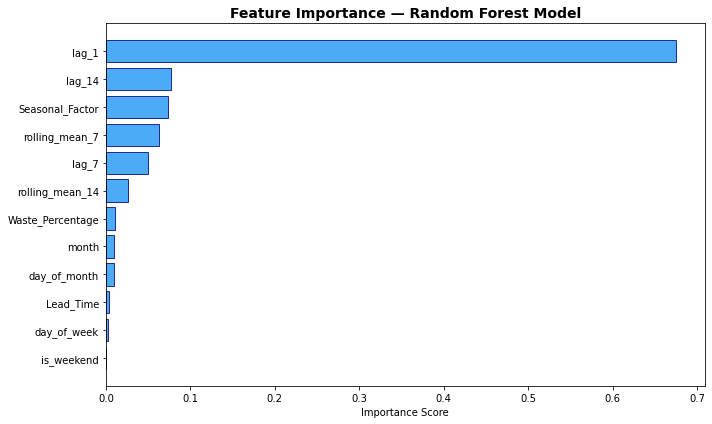

Feature importance chart saved.


In [9]:
# Feature importance chart
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'], color='#2196F3', edgecolor='navy', alpha=0.8)
plt.title('Feature Importance — Random Forest Model', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Feature importance chart saved.')

## Step 7: 7-Day Demand Forecast

In [10]:
def forecast_7_days(item_name, df_features, model, feature_cols):
    """
    Generates a 7-day recursive demand forecast for a given item.
    Recursive = each prediction feeds into the next step as input.
    """
    item_data = df_features[df_features['Item'] == item_name].sort_values('Date').copy()
    last_row   = item_data.iloc[-1].copy()
    last_date  = last_row['Date']
    
    forecasts = []
    recent_usage = list(item_data['Daily_Usage'].tail(14))
    
    for day in range(1, 8):
        forecast_date = last_date + pd.Timedelta(days=day)
        
        # Build feature row
        features = {
            'lag_1':          recent_usage[-1],
            'lag_7':          recent_usage[-7]  if len(recent_usage) >= 7  else recent_usage[0],
            'lag_14':         recent_usage[-14] if len(recent_usage) >= 14 else recent_usage[0],
            'rolling_mean_7': np.mean(recent_usage[-7:]),
            'rolling_mean_14':np.mean(recent_usage[-14:]),
            'day_of_week':    forecast_date.dayofweek,
            'is_weekend':     int(forecast_date.dayofweek >= 5),
            'month':          forecast_date.month,
            'day_of_month':   forecast_date.day,
            'Seasonal_Factor':last_row['Seasonal_Factor'],
            'Waste_Percentage':last_row['Waste_Percentage'],
            'Lead_Time':      last_row['Lead_Time']
        }
        
        pred = model.predict(pd.DataFrame([features]))[0]
        forecasts.append({'Date': forecast_date, 'Item': item_name, 'Forecasted_Usage': round(pred, 1)})
        recent_usage.append(pred)
    
    return pd.DataFrame(forecasts)

# Generate forecasts for all items
all_forecasts = pd.concat([
    forecast_7_days(item, df_features, model, feature_cols)
    for item in df['Item'].unique()
])

print('7-Day Demand Forecast:')
print('=' * 45)
all_forecasts

7-Day Demand Forecast:


,Date,Item,Forecasted_Usage
0,2024-01-01,Rice,75.9
1,2024-01-02,Rice,75.0
2,2024-01-03,Rice,74.5
3,2024-01-04,Rice,77.3
4,2024-01-05,Rice,77.9
5,2024-01-06,Rice,78.0
6,2024-01-07,Rice,78.0
0,2024-01-01,Chicken,64.6
1,2024-01-02,Chicken,65.2
2,2024-01-03,Chicken,66.3


## Step 8: Reorder Recommendation Engine

In [11]:
def generate_reorder_recommendations(forecasts, df):
    """
    Generates reorder recommendations based on:
    - Lead-time demand: how much stock needed during supplier delivery window
    - Safety stock: buffer to handle forecast uncertainty
    - Current stock: what we have right now
    - Reorder quantity: what we need to order
    """
    recommendations = []
    
    for item in forecasts['Item'].unique():
        item_forecast = forecasts[forecasts['Item'] == item]
        item_current  = df[df['Item'] == item].sort_values('Date').iloc[-1]
        
        lead_time         = int(item_current['Lead_Time'])
        current_stock     = item_current['Current_Stock']
        avg_daily_forecast= item_forecast['Forecasted_Usage'].mean()
        
        # Reorder logic
        lead_time_demand  = avg_daily_forecast * lead_time
        safety_stock      = avg_daily_forecast * 1.5   # 1.5 days buffer
        reorder_point     = lead_time_demand + safety_stock
        reorder_quantity  = max(0, round(lead_time_demand + safety_stock - current_stock, 1))
        needs_reorder     = current_stock <= reorder_point
        
        recommendations.append({
            'Item':              item,
            'Current_Stock':     current_stock,
            'Avg_Daily_Forecast':round(avg_daily_forecast, 1),
            'Lead_Time_Days':    lead_time,
            'Safety_Stock':      round(safety_stock, 1),
            'Reorder_Point':     round(reorder_point, 1),
            'Reorder_Quantity':  reorder_quantity,
            'Action':            'ORDER NOW' if needs_reorder else 'Stock OK'
        })
    
    return pd.DataFrame(recommendations)

reorder_df = generate_reorder_recommendations(all_forecasts, df)

print('REORDER RECOMMENDATIONS')
print('=' * 70)
reorder_df

REORDER RECOMMENDATIONS


,Item,Current_Stock,Avg_Daily_Forecast,Lead_Time_Days,Safety_Stock,Reorder_Point,Reorder_Quantity,Action
0,Rice,200,76.7,2,115.0,268.3,68.3,ORDER NOW
1,Chicken,150,69.4,1,104.1,173.4,23.4,ORDER NOW
2,Tomatoes,100,63.7,1,95.6,159.3,59.3,ORDER NOW
3,Onions,120,57.6,1,86.4,144.1,24.1,ORDER NOW
4,Oil,80,18.6,3,28.0,83.9,3.9,ORDER NOW


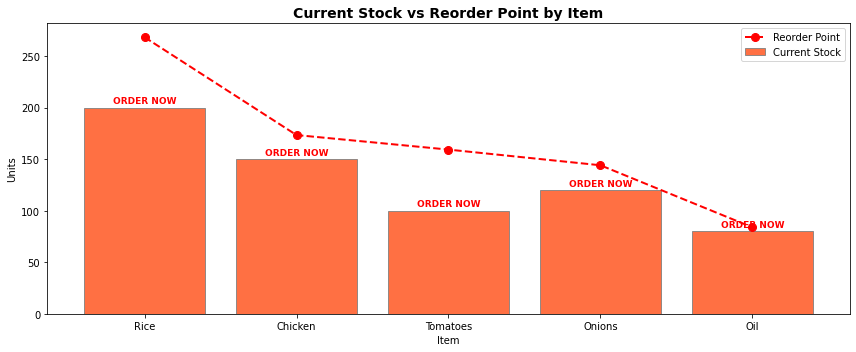

Reorder chart saved.


In [12]:
# Visualise reorder status
colors = ['#FF5722' if a == 'ORDER NOW' else '#4CAF50' for a in reorder_df['Action']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(reorder_df['Item'], reorder_df['Current_Stock'], color=colors, edgecolor='grey', alpha=0.85, label='Current Stock')
ax.plot(reorder_df['Item'], reorder_df['Reorder_Point'], 'r--o', linewidth=2, markersize=8, label='Reorder Point')

ax.set_title('Current Stock vs Reorder Point by Item', fontsize=14, fontweight='bold')
ax.set_xlabel('Item')
ax.set_ylabel('Units')
ax.legend()

# Add action labels on bars
for bar, action in zip(bars, reorder_df['Action']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            action, ha='center', va='bottom', fontsize=9, fontweight='bold',
            color='red' if action == 'ORDER NOW' else 'green')

plt.tight_layout()
plt.savefig('reorder_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Reorder chart saved.')

In [13]:
# Export results to CSV
all_forecasts.to_csv('7_day_forecast_output.csv', index=False)
reorder_df.to_csv('reorder_recommendations_output.csv', index=False)

print('Results exported successfully!')
print('  - 7_day_forecast_output.csv')
print('  - reorder_recommendations_output.csv')
print('\nProject complete!')

Results exported successfully!
  - 7_day_forecast_output.csv
  - reorder_recommendations_output.csv

Project complete!


---
## Summary

This project demonstrated a complete ML-based inventory forecasting pipeline:

| Stage | What was done |
|---|---|
| Data Cleaning | Handled missing values, duplicates, date formatting |
| EDA | Visualised usage trends, identified seasonal patterns |
| Feature Engineering | Lag features, rolling averages, calendar features |
| Model | Random Forest Regressor (200 estimators) |
| Evaluation | MAE & RMSE compared against naive baseline |
| Forecasting | 7-day recursive demand forecast per item |
| Reorder Engine | Lead-time demand + safety stock logic |
| Output | CSV exports + visualisations |

**Business Impact:** Replaced manual spreadsheet-based stock management with an automated, data-driven forecasting system that generates daily reorder recommendations.